In [7]:
import torch
model = torch.hub.load('koleslena/sanskrit_nlp_models', 'cnn_full_pos_tagger_model')

Using cache found in /Users/elenko/.cache/torch/hub/koleslena_sanskrit_nlp_models_main


CNN: vocab_size: 42, labels_num: 734
Количество параметров 87454


In [2]:
model

CNNPOSTagger(
  (char_embeddings): Embedding(42, 64, padding_idx=0)
  (backbone): StackedConv1d(
    (layers): ModuleList(
      (0-2): 3 x Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): Dropout(p=0.3, inplace=False)
        (2): LeakyReLU(negative_slope=0.01)
      )
    )
  )
  (global_pooling): AdaptiveMaxPool1d(output_size=1)
  (out): Linear(in_features=64, out_features=734, bias=True)
)

In [3]:
model.labels_num

734

In [4]:
for param in model.parameters():
    print(param.shape)

torch.Size([42, 64])
torch.Size([64, 64, 3])
torch.Size([64])
torch.Size([64, 64, 3])
torch.Size([64])
torch.Size([64, 64, 3])
torch.Size([64])
torch.Size([734, 64])
torch.Size([734])


In [5]:
p_list = [p.shape for p in model.parameters()]
p_list[0][0]

42

In [9]:
p_list[len(p_list) - 1][0]

734

In [6]:
chars, tags = p_list[0][0], p_list[len(p_list) - 1][0]

In [ ]:
model.char_embeddings

Embedding(42, 64, padding_idx=0)

In [18]:
!python3 -m pip install --upgrade sanskrit_tagger

In [1]:
from sanskrit_tagger.tagger_factory import get_pos_tagger

In [8]:
pos_tagger = get_pos_tagger(model, chars, tags, max_sent_len=1000)
pos_tagger.max_sent_len

1000

In [13]:
test_pos_sentences = [
    'atha kanyā pradāne sa tam eva arthaṁ vicintayan',
    'samāninye ca tat sarvaṁ bhāṇḍaṁ vaivāhikaṁ nṛpaḥ',
    'śrutvā vas tu samagraṃ tad dharma ātmā dharma saṃhitam',
    'sveditaḥ marditaḥ ca eva rañjubhiḥ pariveṣṭitaḥ',
    'ete vo gaṇitā vāsā yatra yatra nivatsyatha',
    'kiṃ kāryaṃ brūta bhavatāṃ bhayaṃ nāśayitāsmi vaḥ',
]
test_pos_sentences_tokenized = [sent.split() for sent in test_pos_sentences]

In [10]:
for sent_tokens, sent_tags in zip(test_pos_sentences_tokenized, pos_tagger(test_pos_sentences)):
    print(' '.join('{}-{}'.format(tok, tag) for tok, tag in zip(sent_tokens, sent_tags)))
    print()

1it [00:00,  2.86it/s]                     

atha-ADV kanyā-NOUN Gen Fem Sing pradāne-NOUN Loc Neut Sing sa-PRON Nom Masc Sing tam-PRON Acc Masc Sing eva-PART arthaṁ-NOUN Cpd vicintayan-VERB Nom Masc Sing Pres Part

samāninye-VERB Pres Ind 1 Sing ca-CONJ tat-PRON Acc Neut Sing sarvaṁ-PRON Cpd bhāṇḍaṁ-NOUN Cpd vaivāhikaṁ-NOUN Voc Masc Sing nṛpaḥ-NOUN Nom Masc Sing

śrutvā-VERB Conv vas-PRON Gen Plur tu-PART samagraṃ-NOUN Acc Masc Sing tad-PRON Acc Neut Sing dharma-NOUN Cpd ātmā-NOUN Nom Masc Sing dharma-NOUN Cpd saṃhitam-VERB Nom Neut Sing Part

sveditaḥ-VERB Nom Masc Sing Part marditaḥ-VERB Nom Masc Sing Part ca-CONJ eva-PART rañjubhiḥ-NOUN Ins Masc Plur pariveṣṭitaḥ-VERB Nom Masc Sing Part

ete-PRON Nom Masc Plur vo-PRON Gen Plur gaṇitā-VERB Nom Masc Plur Part vāsā-NOUN Nom Masc Plur yatra-SCONJ yatra-SCONJ nivatsyatha-VERB Fut Ind 2 Plur

kiṃ-PRON Acc Neut Sing kāryaṃ-VERB Nom Neut Sing Gdv brūta-NOUN Cpd bhavatāṃ-ADJ Gen Masc Plur bhayaṃ-NOUN Acc Masc Sing nāśayitāsmi-VERB Fut Ind peri 1 Sing vaḥ-PRON Gen Plur



In [11]:
import torch
from sanskrit_tagger.tagger_factory import get_pos_tagger

model = torch.hub.load('koleslena/sanskrit_nlp_models', 'bilstm_full_pos_tagger_model')
pos_tagger = get_pos_tagger(model)
pos_tagger

Using cache found in /Users/elenko/.cache/torch/hub/koleslena_sanskrit_nlp_models_main


BLSTM: vocab_size: 40, labels_num: 751
Количество параметров 463983


In [14]:
for sent_tokens, sent_tags in zip(test_pos_sentences_tokenized, pos_tagger(test_pos_sentences)):
    print(' '.join('{}-{}'.format(tok, tag) for tok, tag in zip(sent_tokens, sent_tags)))
    print()

1it [00:00,  7.64it/s]                     

atha-ADV kanyā-NOUN Gen Fem Sing pradāne-NOUN Loc Neut Sing sa-ADV tam-PRON Nom Sing eva-PRON Nom Masc Dual arthaṁ-VERB Past Ind peri 3 Sing vicintayan-VERB Fut Ind 2 Sing

samāninye-VERB Past Ind 3 Plur ca-CONJ tat-PRON Acc Neut Sing sarvaṁ-NOUN Nom Masc Sing bhāṇḍaṁ-VERB Past Ind peri 3 Sing vaivāhikaṁ-VERB Past Ind peri 3 Sing nṛpaḥ-NOUN Nom Masc Sing

śrutvā-VERB Fut Cond 1 Plur vas-PRON Acc Sing tu-PART samagraṃ-NOUN Acc Masc Sing tad-PRON Acc Neut Sing dharma-VERB Past Ind peri 3 Sing ātmā-NOUN Gen Masc Plur dharma-VERB Past Ind peri 3 Sing saṃhitam-VERB Acc Masc Sing Part

sveditaḥ-NOUN Abl Masc Sing marditaḥ-NOUN Abl Neut Sing ca-CONJ eva-PRON Nom Masc Dual rañjubhiḥ-NOUN Ins Masc Plur pariveṣṭitaḥ-VERB Pres Ind 3 Plur

ete-PRON Nom Masc Plur vo-PRON Gen Plur gaṇitā-VERB Nom Masc Plur Pres Part Pass vāsā-NOUN Gen Masc Plur yatra-SCONJ yatra-SCONJ nivatsyatha-VERB Fut Ind 1 Plur

kiṃ-ADV kāryaṃ-VERB Nom Neut Sing Gdv brūta-VERB Pres Ind 3 Plur bhavatāṃ-ADJ Gen Masc Plur bhayaṃ-N

In [5]:
import requests
import array as arr

url = 'https://raw.githubusercontent.com/koleslena/sanskrit_nlp_models/main/output/cnn_full_pos_tagger_model_data.dat'
response = requests.get(url)
file_content = response.content

read_array = arr.array('i')
read_array.frombytes(file_content)

print(read_array)
print(read_array[0])


array('i', [42, 734])
42


In [6]:
import requests
import array as arr

url = 'https://raw.githubusercontent.com/koleslena/sanskrit_nlp_models/main/output/bilstm_pos_tagger_model_data.dat'
response = requests.get(url)
file_content = response.content

read_array = arr.array('i')
read_array.frombytes(file_content)

print(read_array)
print(read_array[0])

array('i', [40, 751])
40


In [8]:
from pos_taggers.bilstm_pos_tagger import BiLSTMTagger

bilstm_pos_tagger_model = BiLSTMTagger(40,
                                        751, 
                                        embedding_size=64,
                                        hidden_dim=64,
                                        layers_n=4, 
                                        dropout=0.3)

bilstm_pos_tagger_model

BiLSTMTagger(
  (char_embeddings): Embedding(40, 64)
  (lstm): LSTM(64, 64, num_layers=4, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=128, out_features=751, bias=True)
  (global_pooling): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [9]:
import array 

def get_loss(file_name):
    with open(file_name, 'r') as f:
        # Read all lines, convert to floats, and add to array
        loaded_array = array.array('d', [float(line) for line in f])

    return loaded_array

train_loss = get_loss('../metrics/bilstm_pos_tagger_model_metrics_1767443715.58595/bilstm_pos_tagger_model_metrics_train.dat')
val_loss = get_loss('../metrics/bilstm_pos_tagger_model_metrics_1767443715.58595/bilstm_pos_tagger_model_metrics_val.dat')

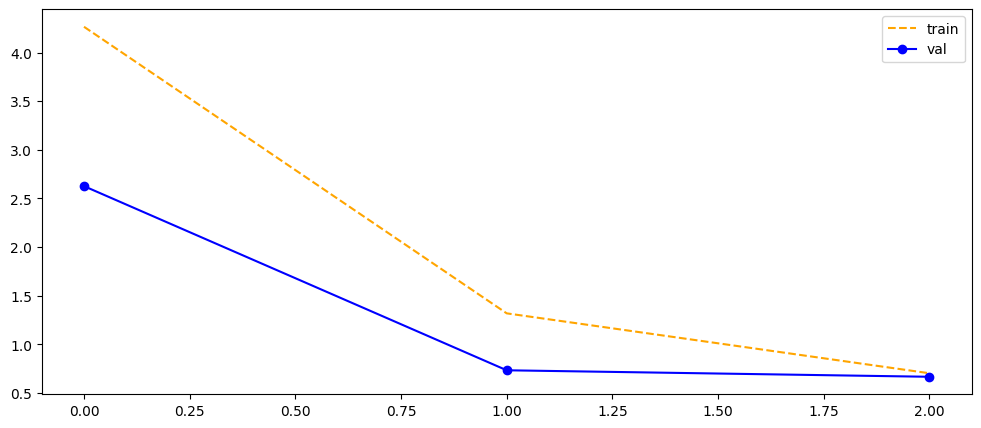

In [10]:
import matplotlib.pyplot as plt

def plot_loss(Loss_train, Loss_val):
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(Loss_train)), Loss_train, color='orange', label='train', linestyle='--')
    plt.plot(range(len(Loss_val)), Loss_val, color='blue', marker='o', label='val')
    plt.legend()
    plt.show()

plot_loss(train_loss, val_loss)

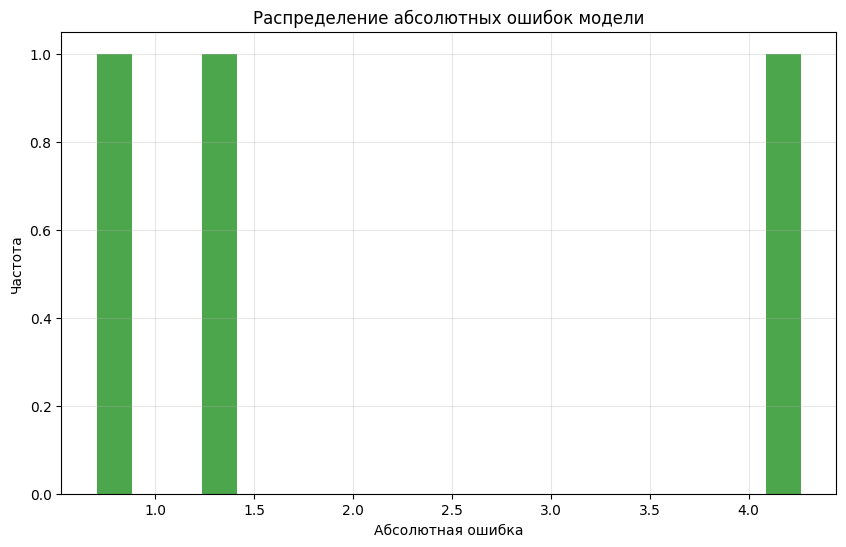

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(loaded_array, bins=20, alpha=0.7, color='green')
plt.title('Распределение абсолютных ошибок модели')
plt.xlabel('Абсолютная ошибка')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()
# plt.savefig(_PLOTS)
# plt.close()